# Visualizing K-means Clustering's Result

Four models are compared:
- **Baseline** (`cluster_risk_scores.csv`) — K-Means on raw PyPI metadata features only
- **GNN (full, 27-dim)** (`gnn_cluster_risk_scores.csv`) — GCL-trained GraphSAGE + K-Means, all features including structural
- **GNN (metadata-only, 20-dim)** (`gnn_cluster_risk_scores2.csv`) — GCL-trained GraphSAGE + K-Means, structural features dropped
- **Raw graph** (`raw_graph_cluster_risk_scores.csv`) — K-Means directly on raw root-node features from the graph dataset (no GNN)

Each CSV has columns: `cluster`, `n_vulnerable`, `cluster_size`, `risk_score`

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

LIB = 'lib'

MODELS = {
    'Baseline\n(metadata only)':          f'{LIB}/cluster_risk_scores.csv',
    'Raw graph\n(no GNN)':                f'{LIB}/raw_graph_cluster_risk_scores.csv',
    'GNN · full (27-dim)':                f'{LIB}/gnn_cluster_risk_scores.csv',
    'GNN · metadata-only (20-dim)':       f'{LIB}/gnn_cluster_risk_scores2.csv',
}

data = {name: pd.read_csv(path) for name, path in MODELS.items()}
print('Loaded CSVs:')
for name, df in data.items():
    print(f'  {name!r:45s}  {len(df)} clusters')

Loaded CSVs:
  'Baseline\n(metadata only)'                    11 clusters
  'Raw graph\n(no GNN)'                          7 clusters
  'GNN · full (27-dim)'                          5 clusters
  'GNN · metadata-only (20-dim)'                 4 clusters


## 1 · Risk score distribution per cluster (per model)

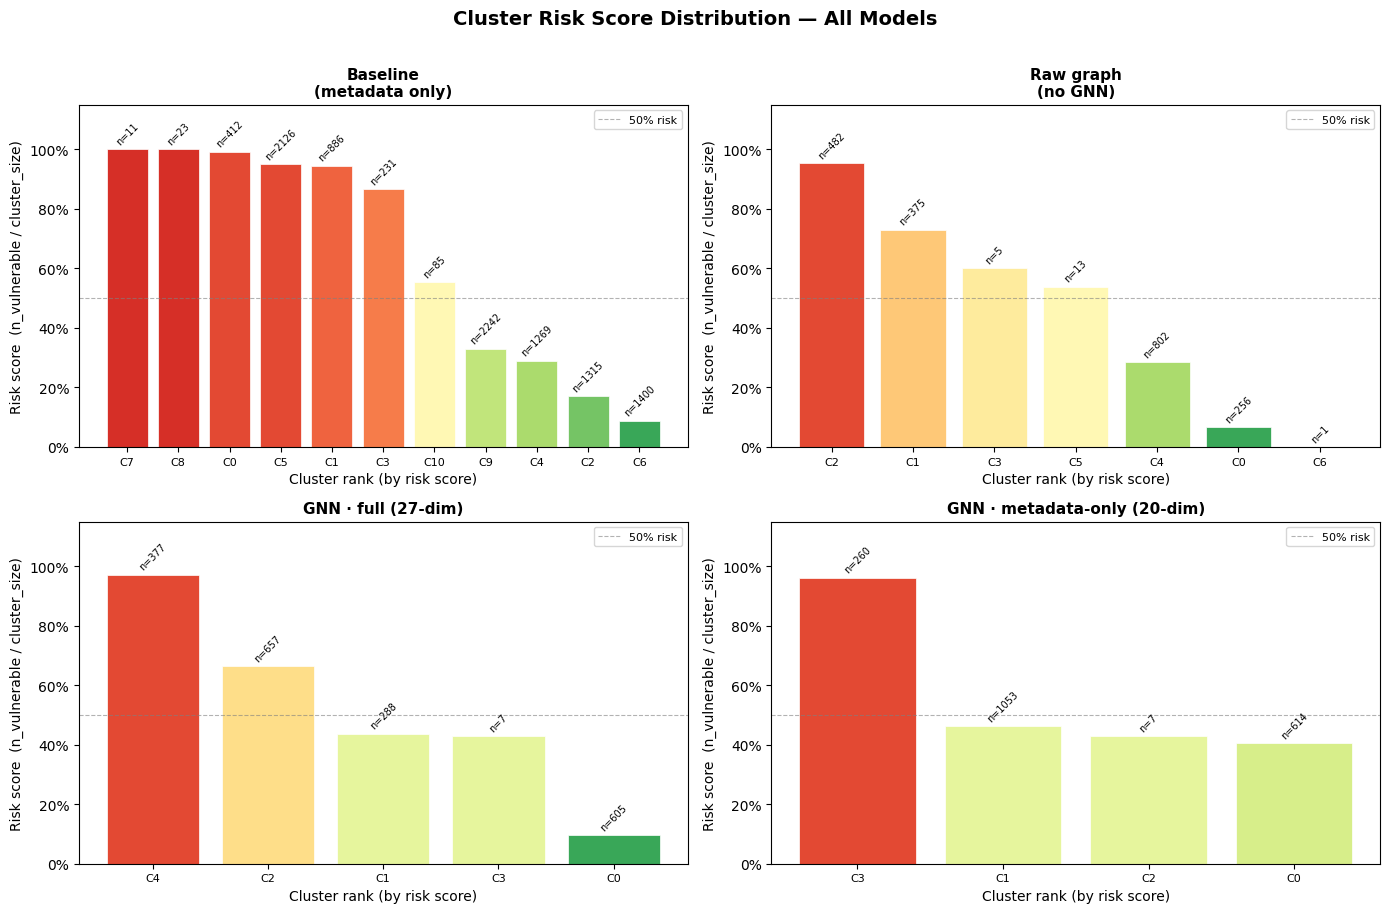

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))  # red=high risk, green=low

for ax, (name, df) in zip(axes, data.items()):
    df_sorted = df.sort_values('risk_score', ascending=False).reset_index(drop=True)
    bar_colors = [colors[min(int(r * 19), 19)] for r in df_sorted['risk_score']]

    bars = ax.bar(
        range(len(df_sorted)),
        df_sorted['risk_score'],
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5,
    )

    # Annotate each bar with cluster size
    for i, (bar, row) in enumerate(zip(bars, df_sorted.itertuples())):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'n={row.cluster_size}',
            ha='center', va='bottom', fontsize=7, rotation=45,
        )

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster rank (by risk score)')
    ax.set_ylabel('Risk score  (n_vulnerable / cluster_size)')
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels([f'C{int(r.cluster)}' for r in df_sorted.itertuples()], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='50% risk')
    ax.legend(fontsize=8)

fig.suptitle('Cluster Risk Score Distribution — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lib/risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Cluster size vs. risk score bubble chart (per model)

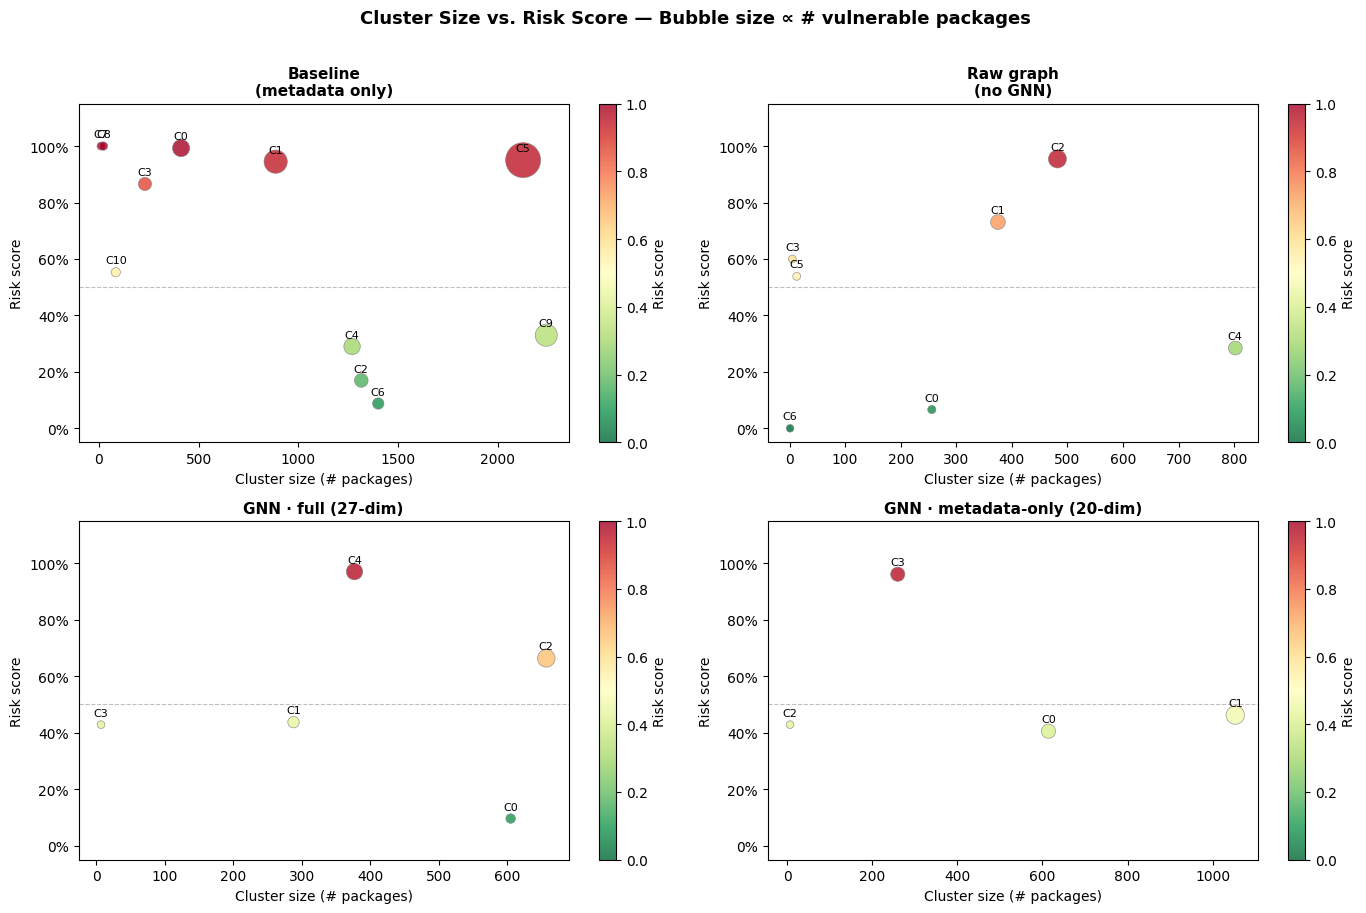

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (name, df) in zip(axes, data.items()):
    sc = ax.scatter(
        df['cluster_size'],
        df['risk_score'],
        s=df['n_vulnerable'] * 0.3 + 30,   # bubble size ∝ # vulnerable packages
        c=df['risk_score'],
        cmap='RdYlGn_r',
        vmin=0, vmax=1,
        alpha=0.8,
        edgecolors='gray',
        linewidths=0.5,
    )
    # Label each bubble with its cluster id
    for _, row in df.iterrows():
        ax.annotate(
            f"C{int(row['cluster'])}",
            (row['cluster_size'], row['risk_score']),
            fontsize=8, ha='center', va='bottom',
            xytext=(0, 5), textcoords='offset points',
        )

    plt.colorbar(sc, ax=ax, label='Risk score')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster size (# packages)')
    ax.set_ylabel('Risk score')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(-0.05, 1.15)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

fig.suptitle('Cluster Size vs. Risk Score — Bubble size ∝ # vulnerable packages',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lib/risk_score_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Model comparison — Recall / Precision / F1 @ top-10% packages

                                Recall  Precision        F1  Flagged packages  True positives  Clusters flagged
Baseline\n(metadata only)     0.492600   0.957621  0.650555            2572.0          2463.0               4.0
Raw graph\n(no GNN)           0.465116   0.954357  0.625425             482.0           460.0               1.0
GNN · full (27-dim)           0.370071   0.970822  0.535871             377.0           366.0               1.0
GNN · metadata-only (20-dim)  0.252781   0.961538  0.400320             260.0           250.0               1.0


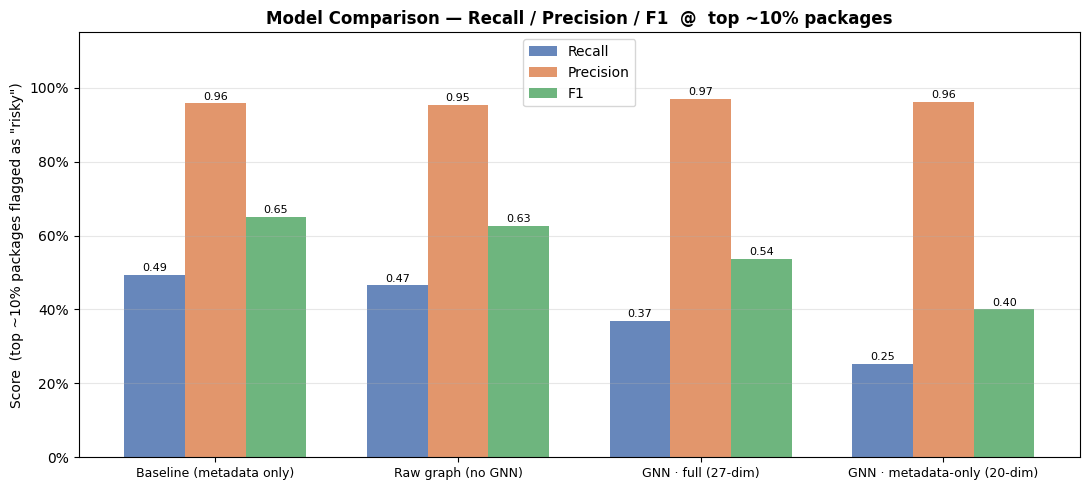

In [8]:
TOP_K_PCT = 0.10

def compute_metrics(df, top_k_pct=TOP_K_PCT):
    """Recall / Precision / F1 for the smallest set of highest-risk clusters
    that covers ~top_k_pct of all packages (package-level Top-K, not cluster-level)."""
    df = df.sort_values('risk_score', ascending=False).reset_index(drop=True)

    total_packages = int(df['cluster_size'].sum())
    n_top_pkgs = max(1, round(total_packages * top_k_pct))

    top_clusters = set()
    n_flagged = 0
    for _, row in df.iterrows():
        top_clusters.add(int(row['cluster']))
        n_flagged += int(row['cluster_size'])
        if n_flagged >= n_top_pkgs:
            break

    total_vulnerable = df['n_vulnerable'].sum()
    top_df           = df[df['cluster'].isin(top_clusters)]
    true_positives   = top_df['n_vulnerable'].sum()
    top_cluster_size = top_df['cluster_size'].sum()

    recall    = true_positives / total_vulnerable if total_vulnerable else 0.0
    precision = true_positives / top_cluster_size if top_cluster_size  else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {'Recall': recall, 'Precision': precision, 'F1': f1,
            'Flagged packages': int(n_flagged), 'True positives': int(true_positives),
            'Clusters flagged': len(top_clusters)}

metrics = {name: compute_metrics(df) for name, df in data.items()}
metrics_df = pd.DataFrame(metrics).T
print(metrics_df.to_string())

# ── Bar chart comparison ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

model_labels = [n.replace('\n', ' ') for n in metrics_df.index]
x      = np.arange(len(model_labels))
width  = 0.25
metric_cols   = ['Recall', 'Precision', 'F1']
metric_colors = ['#4c72b0', '#dd8452', '#55a868']

for i, (col, color) in enumerate(zip(metric_cols, metric_colors)):
    vals = metrics_df[col].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=col, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylabel(f'Score  (top ~{TOP_K_PCT*100:.0f}% packages flagged as "risky")')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=10)
ax.set_title(f'Model Comparison — Recall / Precision / F1  @  top ~{TOP_K_PCT*100:.0f}% packages',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lib/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()